# 02_WL_estimator — Gradient Boosting incremental

- Carga parquet *minimal* (o completo si falta).
- Define fases incrementales de features.
- Split estratificado: train/val/test (70/15/15).
- Modelo: XGBoost (fallback: LightGBM → sklearn GBDT).
- Umbral óptimo por F1 en validación.
- Métricas en test: Accuracy, Balanced Acc, Precision, Recall, F1, ROC-AUC, Brier, Log-loss.
- Gráficos: ROC comparativa y matriz de confusión (fase final).


In [23]:
# Imports básicos
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, average_precision_score, brier_score_loss, log_loss,
    confusion_matrix, roc_curve, auc
)
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler


# Intento de modelos de boosting en orden de preferencia
model_backend = None
try:
    import xgboost as xgb
    model_backend = "xgb"
except Exception:
    try:
        import lightgbm as lgb
        model_backend = "lgbm"
    except Exception:
        from sklearn.ensemble import GradientBoostingClassifier
        model_backend = "sklearn-gbdt"

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 120

DATA_DIR = Path("/Users/pablo/Documents/BigData/BasketballAnalysis/00_data/00d_featurized/00a_WL_prediction")
PARQUET_MINIMAL = DATA_DIR / "teamgamelogs_minimal.parquet"
PARQUET_FULL    = DATA_DIR / "teamgamelogs.parquet"
TARGET = "WL_NUM"
RANDOM_STATE = 42
print("Backend de boosting:", model_backend)

# === Umbral fijo para todas las fases ===
USE_FIXED_THRESHOLD = True
FIXED_THRESHOLD = 0.525  # prueba también 0.55 o 0.60 si quieres afinar
print("Threshold fijo activado:", USE_FIXED_THRESHOLD, FIXED_THRESHOLD)


Backend de boosting: xgb
Threshold fijo activado: True 0.525


## Carga de datos (minimal → fallback a completo) y limpieza rápida
- Quita duplicadas por nombre/contenido.
- Trabaja con numéricas para correlaciones auxiliares.


In [24]:
if PARQUET_MINIMAL.exists():
    df = pd.read_parquet(PARQUET_MINIMAL)
    print(f"Dataset (minimal): {df.shape}")
else:
    df = pd.read_parquet(PARQUET_FULL)
    print(f"Dataset (full): {df.shape}")

if TARGET not in df.columns:
    raise KeyError(f"Falta la columna objetivo '{TARGET}'.")

# Quitar duplicadas por nombre
df = df.loc[:, ~df.columns.duplicated()]

# Quitar duplicadas por contenido
dup_content = df.T.duplicated()
if dup_content.any():
    df = df.loc[:, ~dup_content]
    print("🧹 Eliminadas columnas duplicadas por contenido.")

numeric_df = df.select_dtypes(include=[np.number]).copy()
print("Numéricas:", numeric_df.shape[1])


Dataset (full): (1311, 93)
🧹 Eliminadas columnas duplicadas por contenido.
Numéricas: 87


## Definición de bloques de features y fases incrementales

**BASELINE10:** 10 features top de `DIFF_ROLL10_*` (si el parquet es minimal, ya deberían estar; si no, las calculamos).
**VENUE:** `DIFF_VENUE_HOME_W_PCT`, `DIFF_VENUE_ROAD_W_PCT`
**ENHANCED:** `DIFF_DAYS_REST`, `DIFF_LAST_5_PCT`, `DIFF_WIN_STREAK`, `DIFF_SEASON_W_PCT`, `DIFF_PACE`, `DIFF_TURNOVER_RATIO`
**ELO (reducido):** `P_ELO_HOME`, `DIFF_ELO_DIFF_PRE`


In [25]:
# Detectar candidates baseline roll10
roll10_cols = [c for c in numeric_df.columns if c.startswith("DIFF_ROLL10_") and c != TARGET]

# Si el parquet es minimal, normalmente ya están “las buenas”. Aun así, tomamos las 10 con mayor |corr| por si viniera del completo.
def corr_with_target(df_num, cols, target):
    X = df_num[cols + [target]].dropna()
    if X.empty:
        return pd.DataFrame(columns=["feature","corr","abs_corr"])
    out = pd.DataFrame({
        "feature": cols,
        "corr": [X[c].corr(X[target]) for c in cols]
    })
    out["abs_corr"] = out["corr"].abs()
    return out.sort_values("abs_corr", ascending=False)

df_corr_base = corr_with_target(numeric_df, roll10_cols, TARGET)
baseline10 = df_corr_base.head(10)["feature"].tolist() if not df_corr_base.empty else []

VENUE = [c for c in ["DIFF_VENUE_HOME_W_PCT","DIFF_VENUE_ROAD_W_PCT"] if c in df.columns]
ENHANCED = [c for c in ["DIFF_DAYS_REST","DIFF_LAST_5_PCT","DIFF_WIN_STREAK","DIFF_SEASON_W_PCT","DIFF_PACE","DIFF_TURNOVER_RATIO"] if c in df.columns]
ELO = [c for c in ["P_ELO_HOME","DIFF_ELO_DIFF_PRE"] if c in df.columns]

ID_COLS = [c for c in ["GAME_ID","GAME_DATE","HOME_TEAM_ID","AWAY_TEAM_ID","HOME_COURT"] if c in df.columns]

print("Baseline10:", baseline10)
print("Venue:", VENUE)
print("Enhanced:", ENHANCED)
print("Elo:", ELO)


Baseline10: ['DIFF_ROLL10_PLUS_MINUS', 'DIFF_ROLL10_E_NET_RATING', 'DIFF_ROLL10_OPP_PTS_OFF_TOV', 'DIFF_ROLL10_PTS', 'DIFF_ROLL10_FGM', 'DIFF_ROLL10_DEF_RATING', 'DIFF_ROLL10_FG_PCT', 'DIFF_ROLL10_TOV', 'DIFF_ROLL10_USG_PCT', 'DIFF_ROLL10_OPP_PTS_FB']
Venue: ['DIFF_VENUE_HOME_W_PCT', 'DIFF_VENUE_ROAD_W_PCT']
Enhanced: ['DIFF_DAYS_REST', 'DIFF_LAST_5_PCT', 'DIFF_WIN_STREAK', 'DIFF_SEASON_W_PCT', 'DIFF_PACE', 'DIFF_TURNOVER_RATIO']
Elo: ['P_ELO_HOME', 'DIFF_ELO_DIFF_PRE']


## Construcción de las 4 fases de features
- Fase A: **BASELINE10**
- Fase B: **BASELINE10 + VENUE**
- Fase C: **B + ENHANCED**
- Fase D: **C + ELO**


In [26]:
def uniq(seq):
    s, out = set(), []
    for x in seq:
        if x not in s:
            s.add(x); out.append(x)
    return out

PHASES = {
    "A_BASE10": uniq(baseline10),
    "B_BASE10_VENUE": uniq(baseline10 + VENUE),
    "C_BASE10_VENUE_ENH": uniq(baseline10 + VENUE + ENHANCED),
    "D_BASE10_VENUE_ENH_ELO": uniq(baseline10 + VENUE + ENHANCED + ELO),
}

# Filtra por disponibilidad real
for k, cols in PHASES.items():
    PHASES[k] = [c for c in cols if c in df.columns]
    print(f"{k}: {len(PHASES[k])} columnas")


A_BASE10: 10 columnas
B_BASE10_VENUE: 12 columnas
C_BASE10_VENUE_ENH: 18 columnas
D_BASE10_VENUE_ENH_ELO: 20 columnas


## Split estratificado train/val/test (70/15/15)
- Semilla fija para reproducibilidad.
- Misma partición para todas las fases.


In [27]:
y = df[TARGET].astype(int).values
X_all = df  # seleccionaremos columnas por fase luego

X_train_full, X_temp, y_train, y_temp = train_test_split(
    X_all, y, test_size=0.30, stratify=y, random_state=RANDOM_STATE
)
X_val_full, X_test_full, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=RANDOM_STATE
)

print("Train:", X_train_full.shape[0], "Val:", X_val_full.shape[0], "Test:", X_test_full.shape[0])


Train: 917 Val: 197 Test: 197


## Modelo de Gradient Boosting y utilidades de evaluación
- Usa **XGBoost** si está disponible (fallback: LightGBM → sklearn GBDT).
- Optimiza umbral en validación (máximo F1).
- Calcula todas las métricas en test y devuelve curvas ROC.


In [28]:
def make_model():
    if model_backend == "xgb":
        # Parámetros robustos por defecto para tabular
        return xgb.XGBClassifier(
            n_estimators=800,
            learning_rate=0.07,
            max_depth=5,
            subsample=0.9,
            colsample_bytree=0.9,
            reg_lambda=1.0,
            eval_metric="logloss",
            n_jobs=-1,
            random_state=RANDOM_STATE,
            tree_method="hist"
        )

    elif model_backend == "lgbm":
        return lgb.LGBMClassifier(
            n_estimators=700,
            learning_rate=0.05,
            max_depth=-1,
            num_leaves=31,
            subsample=0.9,
            colsample_bytree=0.9,
            reg_lambda=1.0,
            random_state=RANDOM_STATE
        )
    else:
        from sklearn.ensemble import GradientBoostingClassifier
        return GradientBoostingClassifier(
            n_estimators=400, learning_rate=0.05, max_depth=3, random_state=RANDOM_STATE
        )

def best_threshold_from_val(y_true, proba, metric="f1"):
    grid = np.linspace(0.0, 1.0, 1001)
    best_t, best_m = 0.5, -1.0
    for t in grid:
        pred = (proba >= t).astype(int)
        if metric == "balanced_acc":
            m = balanced_accuracy_score(y_true, pred)
        elif metric == "f1":
            m = f1_score(y_true, pred, zero_division=0)
        else:
            m = f1_score(y_true, pred, zero_division=0)
        if m > best_m:
            best_m, best_t = m, t
    return best_t, best_m

def fit_eval_phase(phase_name, feature_list):
    Xtr = X_train_full[feature_list].copy()
    Xva = X_val_full[feature_list].copy()
    Xte = X_test_full[feature_list].copy()

    pipe = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("model", make_model())
    ])
    pipe.fit(Xtr, y_train)

    proba_val = pipe.predict_proba(Xva)[:, 1] if hasattr(pipe.named_steps["model"], "predict_proba") else pipe.decision_function(Xva)
    proba_tst = pipe.predict_proba(Xte)[:, 1] if hasattr(pipe.named_steps["model"], "predict_proba") else pipe.decision_function(Xte)

    # threshold: fijo si está activado; si no, óptimo por F1 en validación
    if USE_FIXED_THRESHOLD:
        t_opt = float(FIXED_THRESHOLD)
    else:
        t_opt, _ = best_threshold_from_val(y_val, proba_val, metric="f1")

    y_pred = (proba_tst >= t_opt).astype(int)

    metrics = {
        "phase": phase_name,
        "n_features": len(feature_list),
        "threshold": float(t_opt),
        "accuracy": accuracy_score(y_test, y_pred),
        "balanced_acc": balanced_accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_test, proba_tst),
        "avg_precision": average_precision_score(y_test, proba_tst),
        "brier": brier_score_loss(y_test, proba_tst),
        "log_loss": log_loss(y_test, np.clip(proba_tst, 1e-6, 1-1e-6)),
    }
    fpr, tpr, _ = roc_curve(y_test, proba_tst)
    roc_d = {"fpr": fpr, "tpr": tpr, "auc": auc(fpr, tpr)}
    cm = confusion_matrix(y_test, y_pred)
    return metrics, roc_d, cm, proba_tst, y_pred


In [29]:
# === Regresión Logística: fábrica de modelos + tuning de C y de umbral ===

def make_lr(C=1.0, penalty="l2", solver="lbfgs"):
    """
    Pipeline: Imputación (mediana) + Escalado estándar + LogisticRegression (balanced).
    - 'lbfgs' con l2 es estable y rápido para ~decenas de features.
    """
    return Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler(with_mean=True, with_std=True)),
        ("model", LogisticRegression(
            C=C, penalty=penalty, solver=solver, max_iter=2000,
            class_weight="balanced", n_jobs=None, random_state=RANDOM_STATE
        )),
    ])

def best_threshold_from_val(y_true, proba, metric="f1"):
    grid = np.linspace(0.0, 1.0, 1001)
    best_t, best_m = 0.5, -1.0
    for t in grid:
        pred = (proba >= t).astype(int)
        if metric == "balanced_acc":
            m = balanced_accuracy_score(y_true, pred)
        else:
            m = f1_score(y_true, pred, zero_division=0)
        if m > best_m:
            best_m, best_t = m, t
    return best_t, best_m

def tune_lr_on_val(Xtr, ytr, Xva, yva, Cs=(0.1, 0.25, 0.5, 1.0, 2.0, 5.0)):
    """
    Busca el mejor C por F1 en validación (con su propio umbral óptimo).
    Devuelve: pipeline entrenado en train, C óptimo y umbral óptimo.
    """
    best = {"score": -1, "C": None, "thr": 0.5, "pipe": None}
    for C in Cs:
        pipe = make_lr(C=C)
        pipe.fit(Xtr, ytr)
        proba_val = pipe.predict_proba(Xva)[:, 1]
        thr, f1m = best_threshold_from_val(yva, proba_val, metric="f1")
        if f1m > best["score"]:
            best.update({"score": f1m, "C": C, "thr": thr, "pipe": pipe})
    return best["pipe"], best["C"], best["thr"]

def fit_eval_phase_lr(phase_name, feature_list):
    # Selección columnas
    Xtr = X_train_full[feature_list].copy()
    Xva = X_val_full[feature_list].copy()
    Xte = X_test_full[feature_list].copy()

    # Tuning de C y (si procede) umbral en validación
    pipe, C_opt, thr_opt = tune_lr_on_val(Xtr, y_train, Xva, y_val)

    # Si queremos umbral fijo, lo imponemos
    if USE_FIXED_THRESHOLD:
        thr_opt = float(FIXED_THRESHOLD)

    # Probabilidades en test
    proba_tst = pipe.predict_proba(Xte)[:, 1]
    y_pred = (proba_tst >= thr_opt).astype(int)

    # Métricas
    metrics = {
        "phase": phase_name,
        "n_features": len(feature_list),
        "threshold": float(thr_opt),
        "C_opt": float(C_opt),
        "accuracy": accuracy_score(y_test, y_pred),
        "balanced_acc": balanced_accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_test, proba_tst),
        "avg_precision": average_precision_score(y_test, proba_tst),
        "brier": brier_score_loss(y_test, proba_tst),
        "log_loss": log_loss(y_test, np.clip(proba_tst, 1e-6, 1-1e-6)),
    }

    # ROC + matriz de confusión
    fpr, tpr, _ = roc_curve(y_test, proba_tst)
    roc_d = {"fpr": fpr, "tpr": tpr, "auc": auc(fpr, tpr)}
    cm = confusion_matrix(y_test, y_pred)
    return metrics, roc_d, cm, proba_tst, y_pred


## Entrenamiento y evaluación de las 4 fases
Genera:
- Tabla de métricas por fase.
- Curvas ROC superpuestas.
- Matriz de confusión (fase final).


In [30]:
results = []
rocs = {}
cms = {}

for key in ["A_BASE10","B_BASE10_VENUE","C_BASE10_VENUE_ENH","D_BASE10_VENUE_ENH_ELO"]:
    feats = PHASES[key]
    if len(feats) == 0:
        print(f"⚠️ {key}: sin features, se omite.")
        continue
    print(f"Entrenando {key} con {len(feats)} columnas (LogReg)…")
    m, r, cm, proba_tst, y_pred = fit_eval_phase_lr(key, feats)
    results.append(m)
    rocs[key] = r
    cms[key] = cm

metrics_df = pd.DataFrame(results).sort_values("phase").reset_index(drop=True)
metrics_df


Entrenando A_BASE10 con 10 columnas (LogReg)…
Entrenando B_BASE10_VENUE con 12 columnas (LogReg)…
Entrenando C_BASE10_VENUE_ENH con 18 columnas (LogReg)…
Entrenando D_BASE10_VENUE_ENH_ELO con 20 columnas (LogReg)…


,phase,n_features,threshold,C_opt,accuracy,balanced_acc,precision,recall,f1,roc_auc,avg_precision,brier,log_loss
0,A_BASE10,10,0.525,0.10,0.543147,0.551194,0.604938,0.457944,0.521277,0.614642,0.667865,0.244864,0.682141
1,B_BASE10_VENUE,12,0.525,0.25,0.593909,0.604984,0.680000,0.476636,0.560440,0.650052,0.716285,0.237651,0.666397
2,C_BASE10_VENUE_ENH,18,0.525,0.10,0.609137,0.616355,0.678571,0.532710,0.596859,0.654206,0.714588,0.237445,0.666488
3,D_BASE10_VENUE_ENH_ELO,20,0.525,0.10,0.604061,0.610800,0.670588,0.532710,0.593750,0.653167,0.714163,0.237604,0.666935


## ROC comparativa (test)


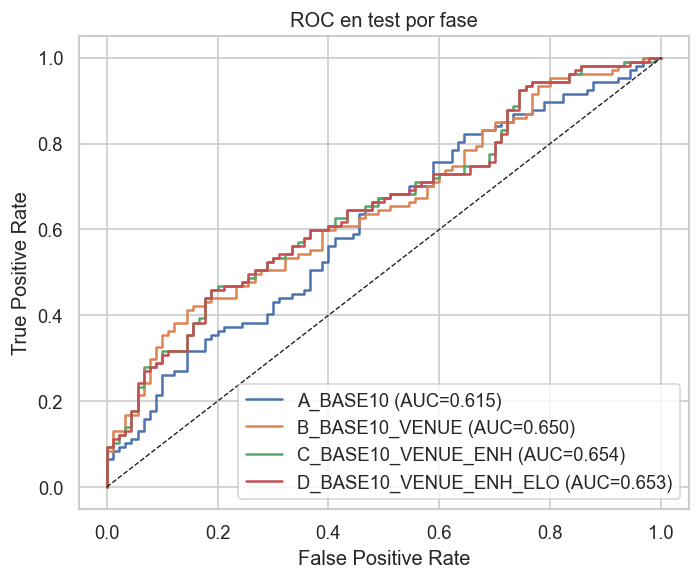

In [31]:
plt.figure(figsize=(6,5))
for key, roc in rocs.items():
    plt.plot(roc["fpr"], roc["tpr"], label=f"{key} (AUC={roc['auc']:.3f})")
plt.plot([0,1],[0,1],'k--', lw=0.8)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC en test por fase")
plt.legend()
plt.tight_layout()
plt.show()


## Matriz de confusión (fase final: D_BASE10_VENUE_ENH_ELO)


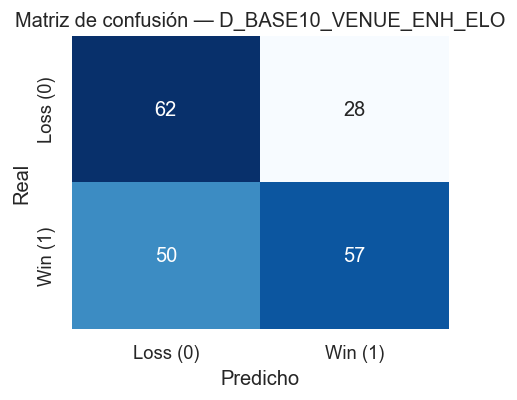

In [32]:
final_key = "D_BASE10_VENUE_ENH_ELO"
if final_key in cms:
    cm = cms[final_key]
    fig, ax = plt.subplots(figsize=(4,3.5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax)
    ax.set_xlabel("Predicho"); ax.set_ylabel("Real")
    ax.set_xticklabels(["Loss (0)","Win (1)"])
    ax.set_yticklabels(["Loss (0)","Win (1)"])
    ax.set_title(f"Matriz de confusión — {final_key}")
    plt.tight_layout(); plt.show()
else:
    print("⚠️ No se encontró la fase final en resultados.")


## Resumen final de métricas (ordenadas por AUC)


In [33]:
display(
    metrics_df.sort_values("roc_auc", ascending=False).reset_index(drop=True)[
        ["phase","n_features","threshold","roc_auc","accuracy","balanced_acc","precision","recall","f1","avg_precision","brier","log_loss"]
    ]
)


,phase,n_features,threshold,roc_auc,accuracy,balanced_acc,precision,recall,f1,avg_precision,brier,log_loss
0,C_BASE10_VENUE_ENH,18,0.525,0.654206,0.609137,0.616355,0.678571,0.532710,0.596859,0.714588,0.237445,0.666488
1,D_BASE10_VENUE_ENH_ELO,20,0.525,0.653167,0.604061,0.610800,0.670588,0.532710,0.593750,0.714163,0.237604,0.666935
2,B_BASE10_VENUE,12,0.525,0.650052,0.593909,0.604984,0.680000,0.476636,0.560440,0.716285,0.237651,0.666397
3,A_BASE10,10,0.525,0.614642,0.543147,0.551194,0.604938,0.457944,0.521277,0.667865,0.244864,0.682141
